<a href="https://colab.research.google.com/github/calebd-1234/vehicle-sales-sql-analysis/blob/main/Food_hub_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
 from google.colab import drive
 drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('foodhub_order.csv')
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


##**Question 1: How many rows and columns are present in the data?**

In [ ]:
df.shape

(1898, 9)

There are 1898 rows and 9 columns

##**Question 2: What are the datatypes of the different columns in the dataset?**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**There are three different types of data types in the data set, float, interger, and object.**

##**Question 3: Are there any missing values in the data? If yes, treat them using an appropriate method.**

In [ ]:
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [ ]:
df['rating'].apply(type).value_counts()

,count
rating,
<class 'str'>,1898


In [ ]:
df['rating'] = df['rating'].replace('Not given', np.nan)
df['rating'] = df['rating'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


Almost 40% of the rating column is missing.

##**Question 4: Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?**


In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


The minimum time it takes for the food to be prepared is 20 minutes, average time is around 27 minutes,and maximum time is 35 minutes.

##**Question 5: How many orders are not rated?**

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


There are 736 orders that are not rated.

#**Observations**:
#**Exploratory** **Data** **Analysis** (**EDA**)
#**Univariate** **Analysis**

##**Question 6: Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)**

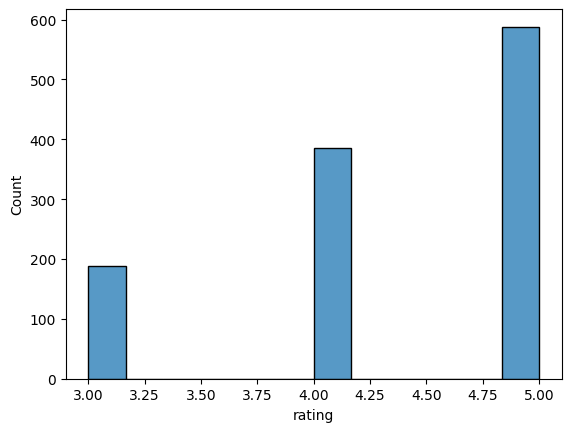

In [ ]:
sns.histplot(df['rating'])
plt.show()

**Of the data given, 5 is the most rating given**

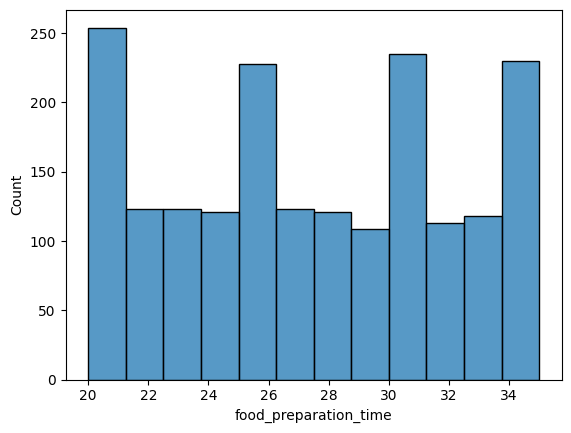

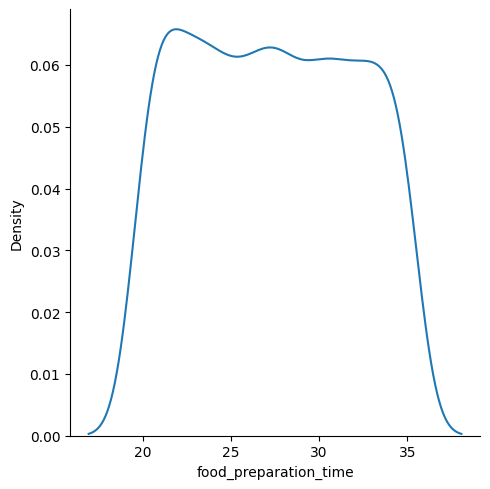

In [ ]:
sns.histplot(df['food_preparation_time'])
plt.show()
sns.displot(data=df,x='food_preparation_time', kind='kde')
plt.show()

**20 minutes is the time that most orders take to prepare, but there are many orders that take much longer to prepare as well.**

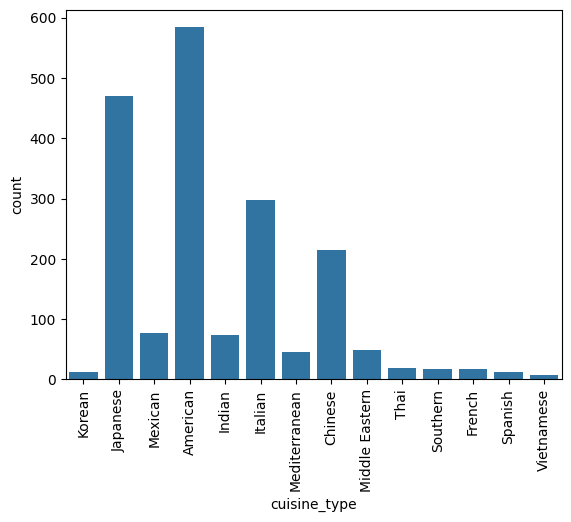

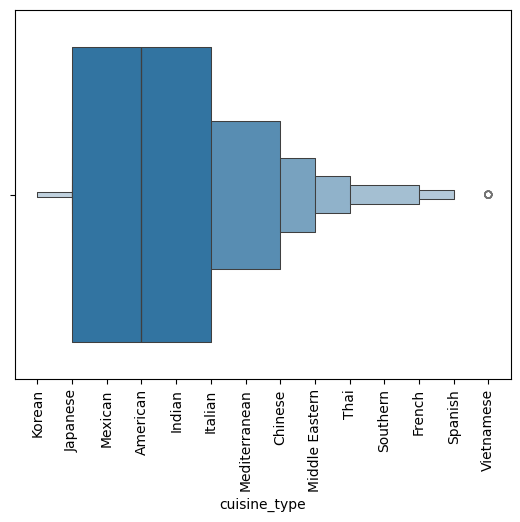

In [ ]:
sns.countplot(data=df,x='cuisine_type')
plt.xticks(rotation=90)
plt.show()
sns.boxenplot(data=df,x='cuisine_type')
plt.xticks(rotation=90)
plt.show()

In [ ]:
cuisine_count = df['cuisine_type'].value_counts().head()
display(cuisine_count)

,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77


**The top 5 cuisine types are American, Japanese, Italian, Chinese, and Mexican. With American being the number one choice in the dataset.**

In [ ]:
from itertools import takewhile
cuisine_count = df['cuisine_type'].value_counts().tail()
display(cuisine_count)

,count
cuisine_type,
French,18
Southern,17
Korean,13
Spanish,12
Vietnamese,7


**The 5 least ordered cuisine types are French, Southern, Korean, Spanish, and Vietnamese. With Vatnamese being the least ordered in the dataset.**

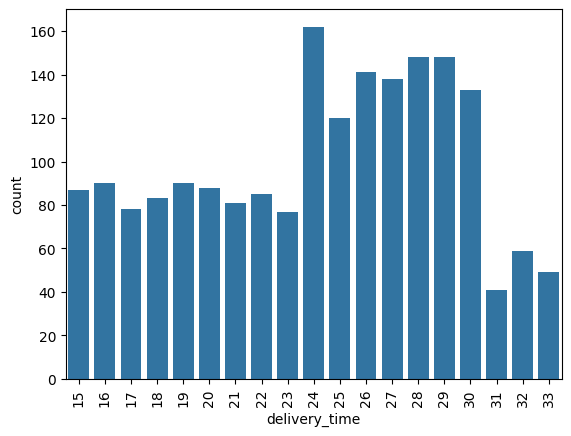

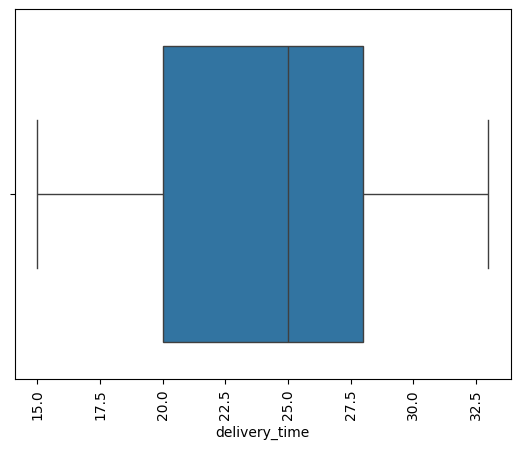

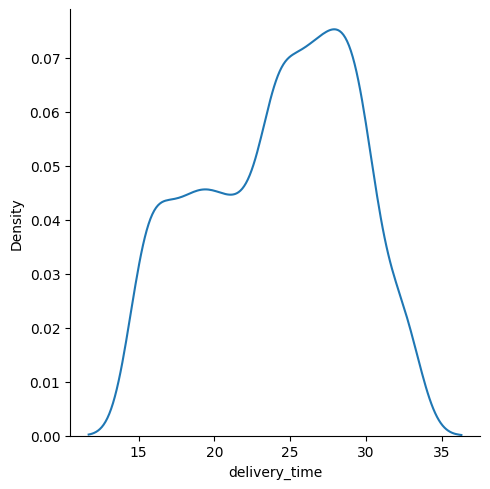

In [ ]:
sns.countplot(data=df,x='delivery_time')
plt.xticks(rotation=90)
plt.show()
sns
sns.boxplot(data=df,x='delivery_time')
plt.xticks(rotation=90)
plt.show()
sns.displot(data=df,x='delivery_time', kind='kde')
plt.show()

**The average delivery time is around 24 minutes with a large amount of deliveries close to 25 minutes.**

<function matplotlib.pyplot.show(close=None, block=None)>

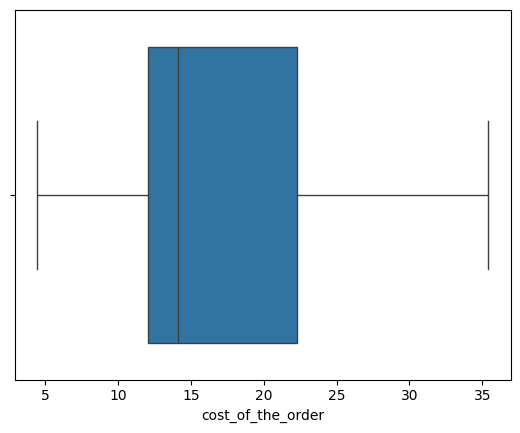

In [ ]:
sns.boxplot(data=df,x='cost_of_the_order')
plt.show

**The average cost per order is around 14 dollars. While other orders are as low as 5 dollars, and as high as 35 dollars.**







In [ ]:
restaurant_counts = df['restaurant_name'].value_counts().head(5)
display(restaurant_counts)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


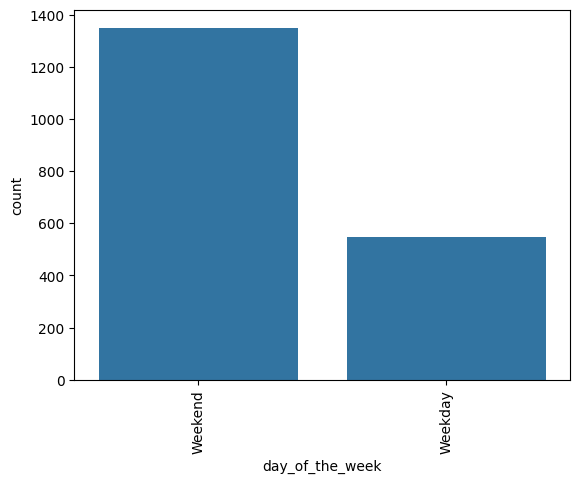

In [ ]:
sns.countplot(data=df, x='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.00,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.00,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5.00,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5.00,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,NaN,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5.00,23,31


In [ ]:
weekday_orders = df[df['day_of_the_week'] != 'Weekend']
percentage_weekday_orders = (len(weekday_orders) / len(df)) * 100

print(f"{percentage_weekday_orders:.2f}% of orders are placed during weekdays.")

28.82% of orders are placed during weekdays.


**Majority of the orders in the dataset occured on the weekends.**

##**Question 7: Which are the top 5 restaurants in terms of the number of orders received?**

In [ ]:
restaurant_counts = df['restaurant_name'].value_counts().head(5)
display(restaurant_counts)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


**The top  restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Shushi, BlueRibbon Fried Chicken, and Parm.**

##**Question 8: Which is the most popular cuisine on weekends?**

In [ ]:
weekend_orders = df[df['day_of_the_week'] == 'Weekend']
most_popular_cuisine_weekend = weekend_orders['cuisine_type'].value_counts().head()
most_popular_cuisine_weekend

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


**The most popular cuisine on the weekend is American.**

##**Question 9: What percentage of the orders cost more than 20 dollars?**

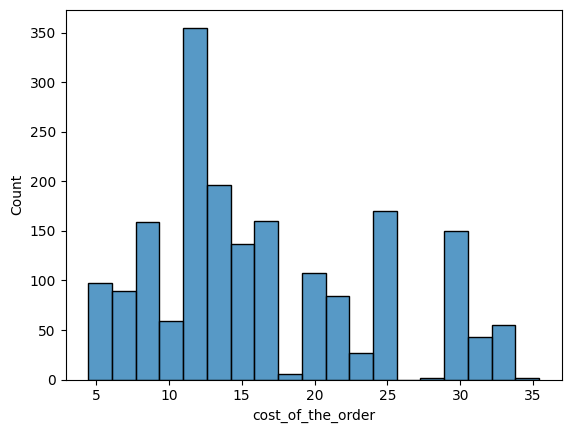

In [ ]:
sns.histplot(data = df,x= 'cost_of_the_order')
plt.show()

In [ ]:
orders_above_20 = df[df['cost_of_the_order'] > 20]
percentage_orders_above_20 = (len(orders_above_20) / len(df)) * 100
percentage_orders_above_20

29.24130663856691

**29% of orders are greater than #20.00.**

##**Question 10: What is the mean order delivery time?**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


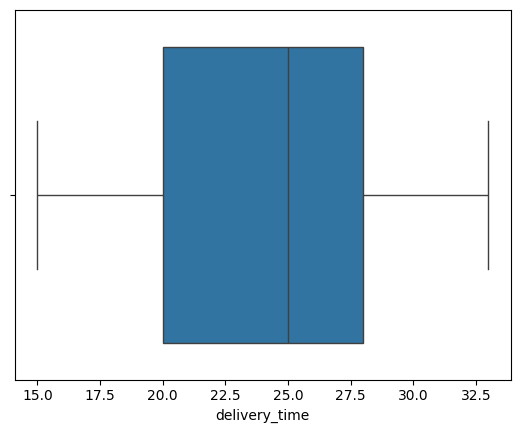

In [ ]:
sns.boxplot(data=df,x='delivery_time')
plt.show()

**The mean delivery time is around 24 minutes.**

##**The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed.**

In [ ]:
customer_count = df['customer_id'].value_counts().head()
display(customer_count)

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


##**Question 12: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)**

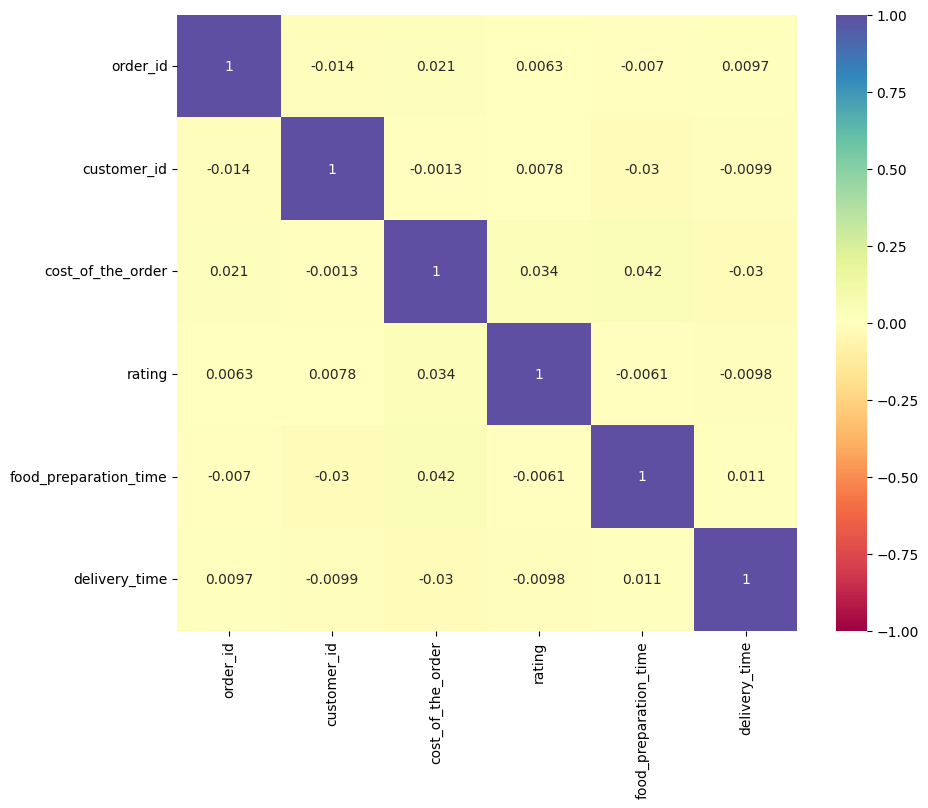

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='Spectral',vmin=-1, vmax=1)
plt.show()

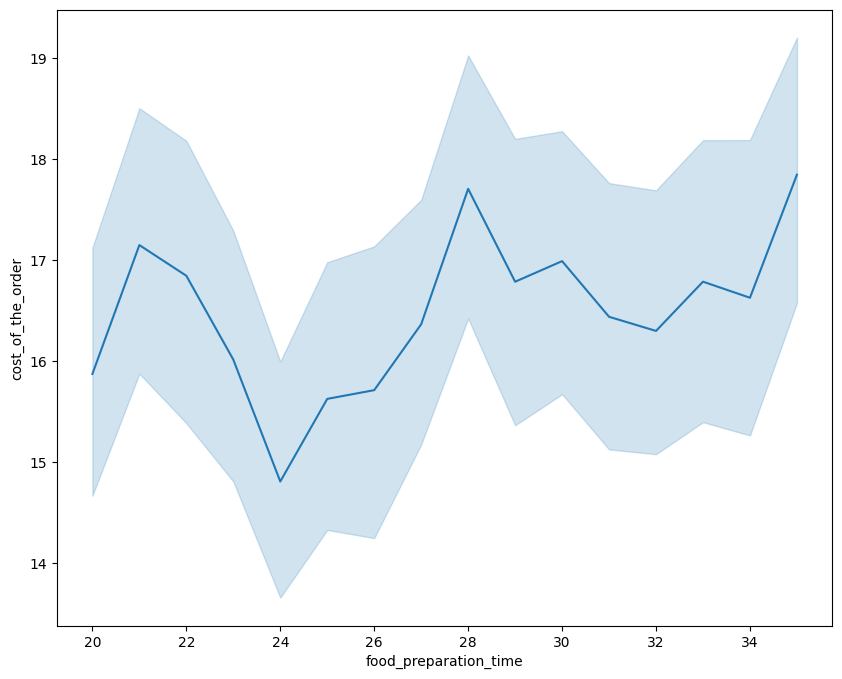

In [ ]:
plt.figure(figsize=(10, 8))
sns.lineplot(data=df, x='food_preparation_time', y='cost_of_the_order')
plt.show()

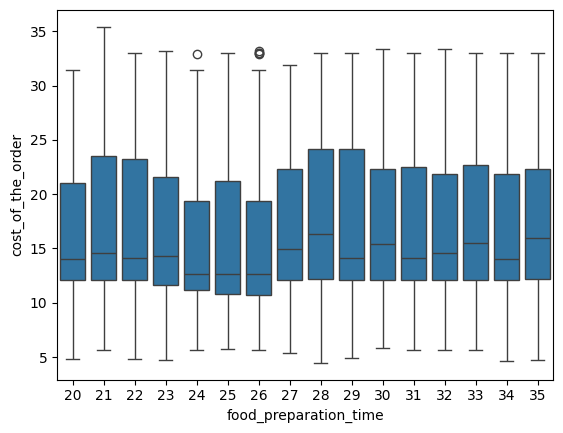

In [ ]:
sns.boxplot(data=df,x='food_preparation_time',y='cost_of_the_order')
plt.show()

**There seems to be a very small correlation between food preperation time and cost of the order, but not one of great concern.**

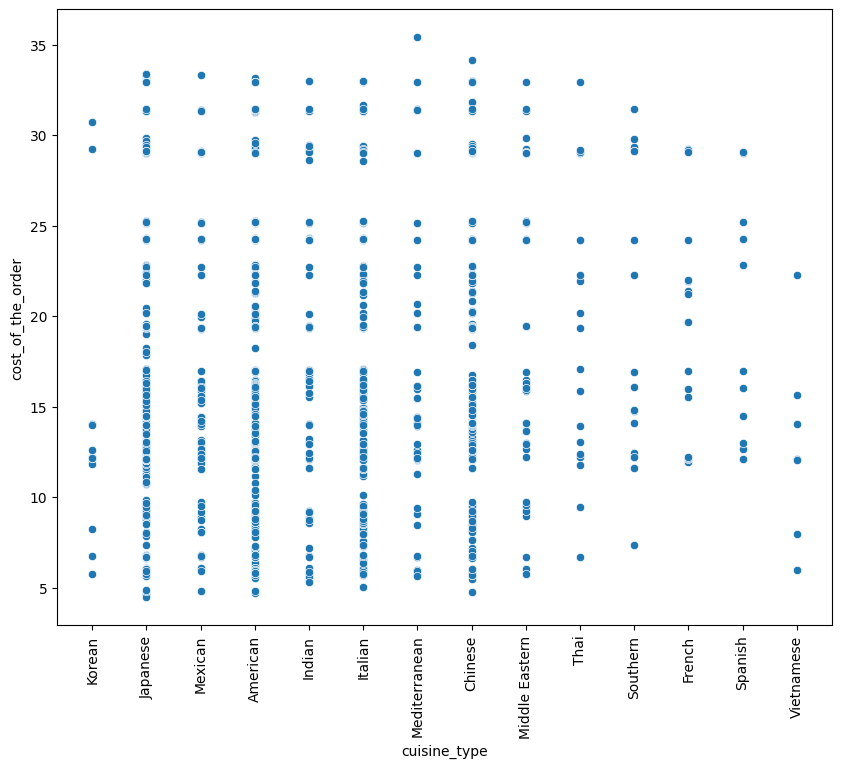

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=90)
plt.show()

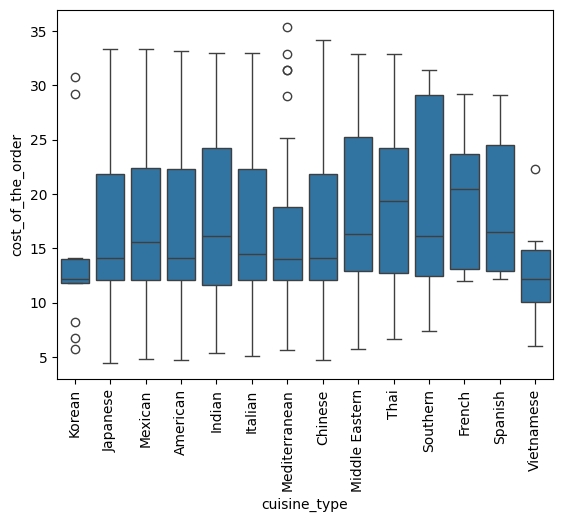

In [ ]:
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order')
plt.xticks(rotation=90)
plt.show()

**French and Spanish seem to start out at a higher price per order. That could possibly be due to cost per dish. Mediterranean shows to have the largest order cost in the dataset.**

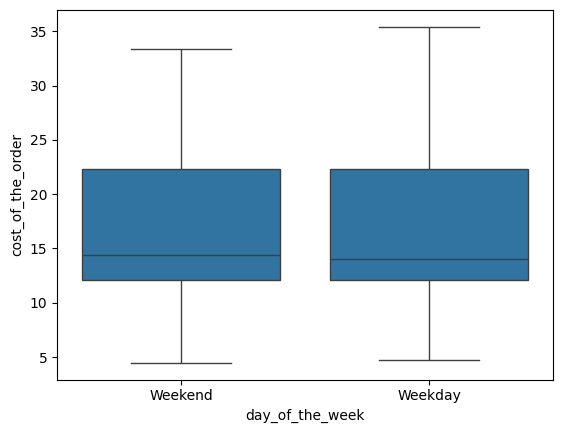

In [ ]:
sns.boxplot(data=df,x='day_of_the_week',y='cost_of_the_order')
plt.show()

**There seem to be some slightly more costly orders of the weekdays.**

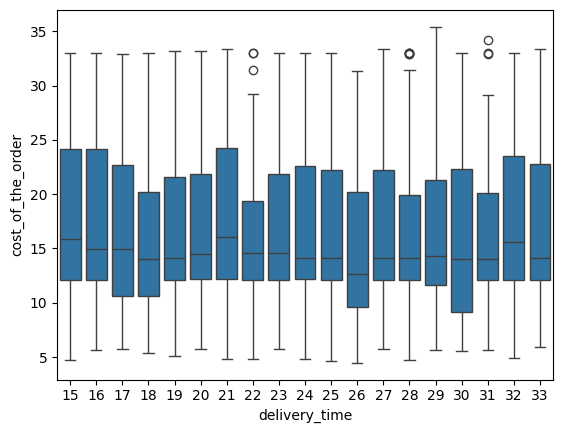

In [ ]:
sns.boxplot(data=df,x='delivery_time',y='cost_of_the_order')
plt.show()


**There seems to be no great correlation between delivery time and cost of orders.**

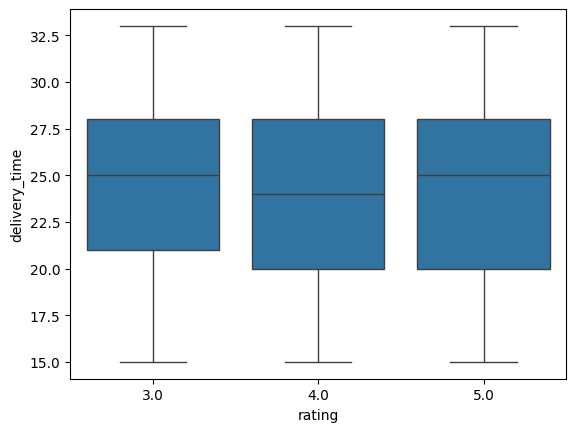

In [ ]:
sns.boxplot(data=df,x='rating',y='delivery_time')
plt.show()

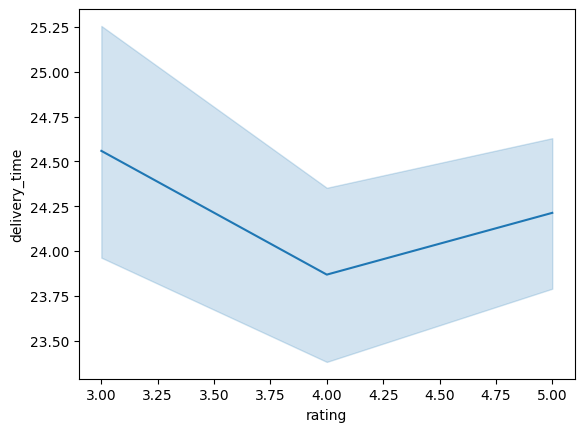

In [ ]:
sns.lineplot(data=df,x='rating',y='delivery_time')
plt.show()

**Interesting enough, there does not seem to be a great correlation between delivery time and rating. Though this is difficult to tell with the missing data.**

##**Question 13: The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.**

In [ ]:
restaurants_for_offer = df.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

eligible_restaurants = restaurants_for_offer[
    (restaurants_for_offer['rating_count'] > 50) &
    (restaurants_for_offer['avg_rating'] > 4)
]

display(eligible_restaurants)

,restaurant_name,rating_count,avg_rating
20,Blue Ribbon Fried Chicken,64,4.33
21,Blue Ribbon Sushi,73,4.22
136,Shake Shack,133,4.28
153,The Meatball Shop,84,4.51


**Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop all fulfill the requirements for the advertisement.**

##**Question 14: The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.**

In [ ]:
df['order_cost'] = pd.cut(df['cost_of_the_order'], bins=[5,20,35],labels=['15%','25%'],right=False)
df['order_cost'].value_counts()

,count
order_cost,
15%,1334
25%,554


In [ ]:
revenue_25_percent = df[df['cost_of_the_order'] > 20]['cost_of_the_order'].sum() * 0.25
revenue_15_percent = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'].sum() * 0.15
total_net_revenue = revenue_25_percent + revenue_15_percent

print(f"Net revenue generated by the company: ${total_net_revenue:.2f}")

Net revenue generated by the company: $6166.30


**The company generated $6166.30**

##**Question 15: The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)**

In [ ]:
df['total_time_to_delivery'] = df['food_preparation_time'] + df['delivery_time']
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,order_cost,total_time_to_delivery
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,25%,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,15%,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.00,23,28,15%,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15,25%,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.00,25,24,15%,49


In [ ]:
orders_gt_60_min = df[df['total_time_to_delivery'] > 60]
percentage_gt_60_min = (len(orders_gt_60_min) / len(df)) * 100
percentage_gt_60_min

10.537407797681771

**%10.54 of orders take longer than 60 minutes to prepare and deliver.**

##**Question 16: The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?**

In [ ]:
mean_delivery_time_weekday = df[df['day_of_the_week'] != 'Weekend']['delivery_time'].mean()
mean_delivery_time_weekend = df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()

print(f"Mean delivery time on weekdays: {mean_delivery_time_weekday:.2f} minutes")
print(f"Mean delivery time on weekends: {mean_delivery_time_weekend:.2f} minutes")

Mean delivery time on weekdays: 28.34 minutes
Mean delivery time on weekends: 22.47 minutes


**Mean delivery time on weekdays is 28.34 minutes, and the mean delivery time on the weekends is 22.47 minutes.**

##**Question 17: What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)**

##**Conclusions:**
**There are several orders that do not have a rating. American is the most favorite cuisine type that is in the dataset. For the ratings that we have, there does not seem to be a noticeble difference in ratings from orders that take a long time to deliver and those that do not. There seems to be a lesser amount of orders from cuisine types that possibly cost more like French and Spanish.**
##**Recommendations:**
**It would be helpful to be able to get more ratings, so possibly do a campaign to boost number of ratings. I think that it is a good idea to do the promotional program for the top ranking restaurants, but it may be beneficial to the lower companies to do a promotional program for them as well. This will possibly give them a boost in business and give them a better reason for using your company. By doing that, you may be able to increase the number of businesses in the 25% range and boost company profits. I would begin this program by focusing on the restaurants that are in the top five cuisines like American, Japanese, Itialian, Mexican, and Chinese and are still below the number of ratings. Another thing that can be done, is to do something to enhance the number of orders during the week.  The Data shows that there is a major decrease between the number of orders during the weekdays compared to the weekends. Less than thirty percent of all orders are during the week.**